In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns

vn30_tickers = [
    'ACB.VN', 'BCM.VN', 'BID.VN', 'BVH.VN', 'CTG.VN',
    'FPT.VN', 'GAS.VN', 'GVR.VN', 'HDB.VN', 'HPG.VN',
    'MBB.VN', 'MSN.VN', 'MWG.VN', 'PLX.VN', 'PNJ.VN',
    'POW.VN', 'SAB.VN', 'SHB.VN', 'SSB.VN', 'SSI.VN',
    'STB.VN', 'TCB.VN', 'TPB.VN', 'VCB.VN', 'VHM.VN',
    'VIB.VN', 'VIC.VN', 'VJC.VN', 'VNM.VN', 'VPB.VN',
    'VRE.VN'
]

print("--- BƯỚC 1: TẢI DỮ LIỆU GIÁ VÀ KHỐI LƯỢNG ---")

try:
    # Tải dữ liệu thô
    data = yf.download(vn30_tickers, start="2022-01-01", end="2026-01-01", group_by='column')

    # Tách Giá (Close) và Khối lượng (Volume)

    df_price = data['Close']
    df_volume = data['Volume']

    print(f"\nKích thước ban đầu: {df_price.shape[1]} mã")

    #  LỌC SẠCH DỮ LIỆU
    # 1. Xóa các mã (cột) không có dữ liệu
    df_price = df_price.dropna(axis=1, how='all')
    df_volume = df_volume[df_price.columns]

    # 2. Điền dữ liệu thiếu
    df_price = df_price.ffill().bfill()
    df_volume = df_volume.ffill().bfill()


    valid_tickers = df_price.columns.tolist()
    print(f"Kích thước sau khi làm sạch: {len(valid_tickers)} mã (Đã loại bỏ các mã lỗi)")

except Exception as e:
    print(f"Lỗi tải dữ liệu: {e}")

print("\n--- BƯỚC 2: TẢI CHỈ SỐ TÀI CHÍNH (CHỈ TẢI CÁC MÃ CÒN LẠI) ---")
fundamental_data = []

for ticker in valid_tickers:
    try:
        stock = yf.Ticker(ticker)
        info = stock.info


        data_item = {
            'Ticker': ticker.replace('.VN', ''),
            'P/E': info.get('trailingPE'),
            'P/B': info.get('priceToBook'),
            'Beta': info.get('beta'),
            'ROE': info.get('returnOnEquity'),
            'Market Cap': info.get('marketCap')
        }
        fundamental_data.append(data_item)
        print(f"Đã lấy chỉ số: {ticker}")
    except:
        print(f"Bỏ qua chỉ số mã: {ticker}")

df_fundamentals = pd.DataFrame(fundamental_data)

print("\n--- BƯỚC 3: XUẤT FILE EXCEL CHUẨN ---")
file_name = 'Dulieu_VN30_Final_Clean.xlsx'


with pd.ExcelWriter(file_name) as writer:
    df_price.to_excel(writer, sheet_name='Lich_su_Gia')
    df_volume.to_excel(writer, sheet_name='Lich_su_Khoi_luong')
    df_fundamentals.to_excel(writer, sheet_name='Chi_so_Tai_chinh')

print(f"Đã tạo file '{file_name}' thành công!")

# Tải về máy
#from google.colab import files
#files.download(file_name)

/tmp/ipython-input-1039209367.py:19: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*****                 10%                       ]  3 of 31 completed

--- BƯỚC 1: TẢI DỮ LIỆU GIÁ VÀ KHỐI LƯỢNG ---


[*********************100%***********************]  31 of 31 completed



Kích thước ban đầu: 31 mã
Kích thước sau khi làm sạch: 31 mã (Đã loại bỏ các mã lỗi)

--- BƯỚC 2: TẢI CHỈ SỐ TÀI CHÍNH (CHỈ TẢI CÁC MÃ CÒN LẠI) ---
Đã lấy chỉ số: ACB.VN
Đã lấy chỉ số: BCM.VN
Đã lấy chỉ số: BID.VN
Đã lấy chỉ số: BVH.VN
Đã lấy chỉ số: CTG.VN
Đã lấy chỉ số: FPT.VN
Đã lấy chỉ số: GAS.VN
Đã lấy chỉ số: GVR.VN
Đã lấy chỉ số: HDB.VN
Đã lấy chỉ số: HPG.VN
Đã lấy chỉ số: MBB.VN
Đã lấy chỉ số: MSN.VN
Đã lấy chỉ số: MWG.VN
Đã lấy chỉ số: PLX.VN
Đã lấy chỉ số: PNJ.VN
Đã lấy chỉ số: POW.VN
Đã lấy chỉ số: SAB.VN
Đã lấy chỉ số: SHB.VN
Đã lấy chỉ số: SSB.VN
Đã lấy chỉ số: SSI.VN
Đã lấy chỉ số: STB.VN
Đã lấy chỉ số: TCB.VN
Đã lấy chỉ số: TPB.VN
Đã lấy chỉ số: VCB.VN
Đã lấy chỉ số: VHM.VN
Đã lấy chỉ số: VIB.VN
Đã lấy chỉ số: VIC.VN
Đã lấy chỉ số: VJC.VN
Đã lấy chỉ số: VNM.VN
Đã lấy chỉ số: VPB.VN
Đã lấy chỉ số: VRE.VN

--- BƯỚC 3: XUẤT FILE EXCEL CHUẨN ---
Đã tạo file 'Dulieu_VN30_Final_Clean.xlsx' thành công!


In [ ]:
import pandas as pd
import numpy as np

#  ĐỌC DỮ LIỆU
file_path = 'Dulieu_VN30_Final_Clean.xlsx'
df_prices = pd.read_excel(file_path, sheet_name='Lich_su_Gia', index_col=0)
df_volume = pd.read_excel(file_path, sheet_name='Lich_su_Khoi_luong', index_col=0)
df_fundamentals = pd.read_excel(file_path, sheet_name='Chi_so_Tai_chinh')

#  ĐỒNG BỘ TÊN MÃ
df_prices.columns = df_prices.columns.str.replace('.VN', '', regex=False)
df_volume.columns = df_volume.columns.str.replace('.VN', '', regex=False)
if 'Ticker' in df_fundamentals.columns:
    df_fundamentals['Ticker'] = df_fundamentals['Ticker'].astype(str).str.replace('.VN', '', regex=False)
    df_fundamentals.set_index('Ticker', inplace=True)

#  TÍNH TOÁN CÁC ĐẶC TRƯNG (FEATURES)
# a. Lợi suất & Rủi ro
daily_returns = df_prices.pct_change().dropna()
annual_returns = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)

# b. Sharpe Ratio
sharpe_ratio = annual_returns / annual_volatility

# c. Thanh khoản (Liquidity)
# Chỉ tính trên các mã và ngày chung
common_idx = df_prices.index.intersection(df_volume.index)
common_col = df_prices.columns.intersection(df_volume.columns)
# Tính giá trị giao dịch trung bình (Tỷ VNĐ)
avg_liquidity = (df_prices.loc[common_idx, common_col] * df_volume.loc[common_idx, common_col]).mean() / 1_000_000_000

# TỔNG HỢP DỮ LIỆU (Tạo bảng df_final gốc)
df_final = pd.DataFrame({
    'Returns': annual_returns,
    'Volatility': annual_volatility,
    'Sharpe_Ratio': sharpe_ratio,
    'Liquidity': avg_liquidity
})

# Ghép thêm P/E, P/B
df_final = df_final.join(df_fundamentals[['P/E', 'P/B']], how='inner')

#  XỬ LÝ DỮ LIỆU THIẾU (IMPUTATION)

df_final = df_final.fillna(df_final.median())

print("--- BƯỚC 1 HOÀN TẤT: DỮ LIỆU ĐÃ SẠCH SẼ ---")
print(df_final.head())

--- BƯỚC 1 HOÀN TẤT: DỮ LIỆU ĐÃ SẠCH SẼ ---
      Returns  Volatility  Sharpe_Ratio   Liquidity        P/E       P/B
ACB  0.127940    0.257647      0.496570  233.457649   7.974482  1.309710
BCM -0.030276    0.235714     -0.128445   32.295389  19.607843  3.279489
BID  0.139576    0.311003      0.448793  104.936695  18.796993  2.252079
BVH  0.089185    0.229278      0.388981   33.833053  19.120459  2.113181
CTG  0.180834    0.313550      0.576731  249.883671   9.025270  1.783939


Các cột dữ liệu được đưa vào mô hình: ['Returns', 'Volatility', 'Sharpe_Ratio', 'Liquidity', 'P/E', 'P/B']
--- ĐANG CHẠY THỬ NGHIỆM TÌM SỐ CỤM (K) ---


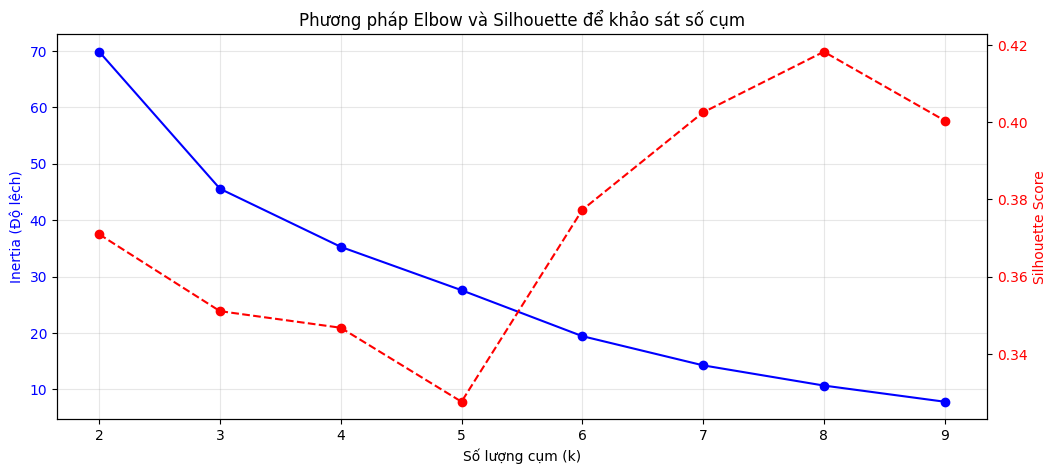

--> Đã quyết định chọn số cụm tối ưu cho VN30 là: k = 3

--- BƯỚC 2 HOÀN TẤT: ĐÃ PHÂN THÀNH 3 CỤM ---
Số lượng cổ phiếu trong từng nhóm:
Cluster
0     9
1    12
2    10
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# CHUẨN BỊ DỮ LIỆU AN TOÀN
# Chỉ lấy các cột số liệu gốc, loại bỏ cột 'Cluster' nếu lỡ đã chạy trước đó
# Danh sách các cột đặc trưng cần thiết
feature_cols = ['Returns', 'Volatility', 'Sharpe_Ratio', 'Liquidity', 'P/E', 'P/B']

# Kiểm tra xem các cột này có trong df_final chưa
valid_cols = [c for c in feature_cols if c in df_final.columns]

print(f"Các cột dữ liệu được đưa vào mô hình: {valid_cols}")

# Lấy dữ liệu sạch để chuẩn hóa
X_input = df_final[valid_cols].copy()

#  CHUẨN HÓA DỮ LIỆU
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_input)

#  GIẢM CHIỀU (PCA)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'], index=df_final.index)

print("--- ĐANG CHẠY THỬ NGHIỆM TÌM SỐ CỤM (K) ---")

#  VÒNG LẶP VẼ BIỂU ĐỒ ELBOW/SILHOUETTE
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(pca_data)
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(pca_data, kmeans_test.labels_))

#  VẼ BIỂU ĐỒ
fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow
ax1.plot(K_range, inertia, 'bo-', label='Inertia')
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia (Độ lệch)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

# Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Phương pháp Elbow và Silhouette để khảo sát số cụm')
plt.show()

# CHỌN K VÀ CHẠY MÔ HÌNH

best_k = 3
print(f"--> Đã quyết định chọn số cụm tối ưu cho VN30 là: k = {best_k}")

# Chạy KMeans với k=3
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(pca_data)

#  GÁN KẾT QUẢ VÀO DỮ LIỆU
# Cập nhật lại cột Cluster cho df_final
df_final['Cluster'] = clusters
df_pca['Cluster'] = clusters

# Tạo bảng dữ liệu chuẩn hóa có nhãn (để vẽ Radar Chart ở Ô 3)
df_scaled_labeled = pd.DataFrame(X_scaled, columns=valid_cols, index=df_final.index)
df_scaled_labeled['Cluster'] = clusters

print(f"\n--- BƯỚC 2 HOÀN TẤT: ĐÃ PHÂN THÀNH {best_k} CỤM ---")
# Đếm xem mỗi nhóm có bao nhiêu mã
print("Số lượng cổ phiếu trong từng nhóm:")
print(df_final['Cluster'].value_counts().sort_index())

--- ĐANG VẼ RADAR CHART ---



--- ĐANG VẼ BOX PLOT ---


/tmp/ipython-input-588055683.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-588055683.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-588055683.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-588055683.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




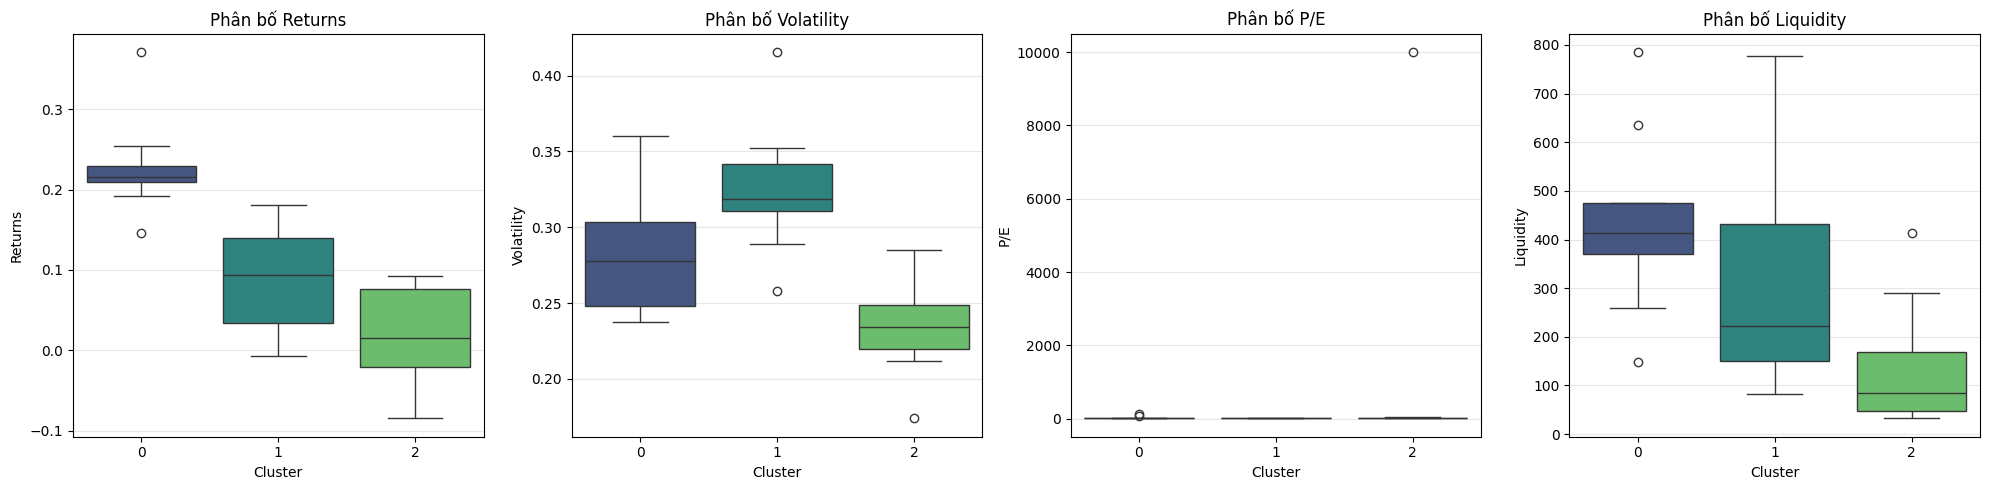


--- ĐANG VẼ 3D SCATTER ---


In [ ]:
import plotly.express as px

# RADAR CHART (Dùng dữ liệu chuẩn hóa df_scaled_labeled)
print("--- ĐANG VẼ RADAR CHART ---")
cluster_centers = df_scaled_labeled.groupby('Cluster').mean().reset_index()
df_melted = cluster_centers.melt(id_vars=['Cluster'], var_name='Chỉ số', value_name='Z-Score')
df_melted['Cluster'] = df_melted['Cluster'].astype(str).apply(lambda x: f'Nhóm {x}')

fig1 = px.line_polar(df_melted, r='Z-Score', theta='Chỉ số', color='Cluster',
                    line_close=True, markers=True, title="Hồ sơ đặc trưng các nhóm (Radar Chart)")
fig1.update_traces(fill='toself', opacity=0.3)
fig1.show()

#  BOX PLOT (Dùng dữ liệu gốc df_final để nhìn giá trị thật)
print("\n--- ĐANG VẼ BOX PLOT ---")
features = ['Returns', 'Volatility', 'P/E', 'Liquidity']
n_cols = len(features)
plt.figure(figsize=(5 * n_cols, 5))

for i, col in enumerate(features):
    plt.subplot(1, n_cols, i+1)
    # Vẽ từ df_final (giá trị thực) để dễ nhận xét
    sns.boxplot(x='Cluster', y=col, data=df_final, palette='viridis')
    plt.title(f'Phân bố {col}')
    plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3D SCATTER (Dùng dữ liệu PCA)
print("\n--- ĐANG VẼ 3D SCATTER ---")
pca_3d = PCA(n_components=3)
components_3d = pca_3d.fit_transform(X_scaled) # Dùng X_scaled xuyên suốt
df_3d = pd.DataFrame(components_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Cluster'] = clusters
df_3d['Ticker'] = df_final.index

fig3 = px.scatter_3d(df_3d, x='PC1', y='PC2', z='PC3', color='Cluster', text='Ticker',
                     opacity=0.8, size_max=10, title='Không gian 3 chiều các nhóm VN30')
fig3.update_traces(marker=dict(size=5), textposition='top center')
fig3.show()

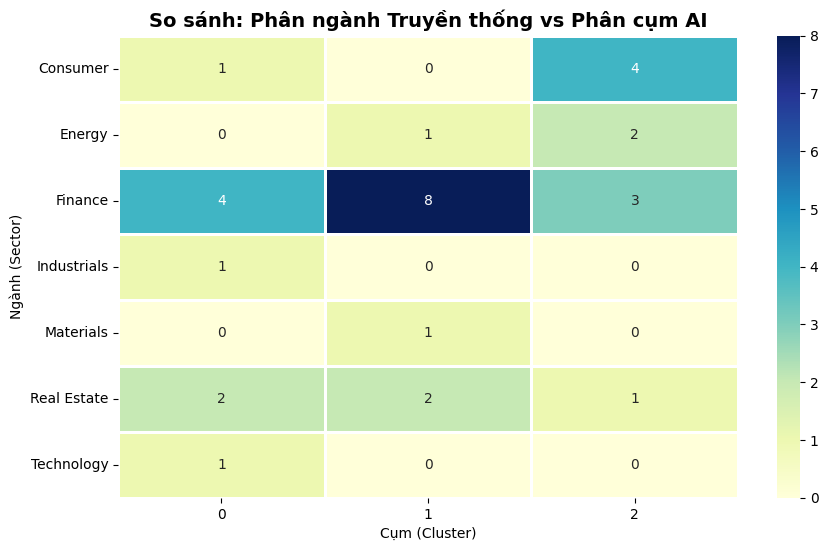

In [ ]:
# MAPPING NGÀNH
sector_mapping = {
    'ACB': 'Finance', 'BID': 'Finance', 'BVH': 'Finance', 'CTG': 'Finance',
    'HDB': 'Finance', 'MBB': 'Finance', 'SHB': 'Finance', 'SSB': 'Finance',
    'STB': 'Finance', 'TCB': 'Finance', 'TPB': 'Finance', 'VCB': 'Finance',
    'VIB': 'Finance', 'VPB': 'Finance', 'SSI': 'Finance',
    'BCM': 'Real Estate', 'KDH': 'Real Estate', 'NVL': 'Real Estate',
    'PDR': 'Real Estate', 'VHM': 'Real Estate', 'VIC': 'Real Estate',
    'VRE': 'Real Estate', 'GVR': 'Real Estate',
    'MSN': 'Consumer', 'VNM': 'Consumer', 'SAB': 'Consumer', 'MWG': 'Consumer', 'PNJ': 'Consumer',
    'FPT': 'Technology', 'GAS': 'Energy', 'POW': 'Energy', 'PLX': 'Energy', 'HPG': 'Materials', 'VJC': 'Industrials'
}

# TẠO BẢNG SO SÁNH (Lấy từ df_final)
df_compare = df_final.copy()
df_compare['Sector'] = df_compare.index.map(sector_mapping).fillna('Other')

#  VẼ HEATMAP
crosstab = pd.crosstab(df_compare['Sector'], df_compare['Cluster'])

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu', linewidths=1, linecolor='white')
plt.title('So sánh: Phân ngành Truyền thống vs Phân cụm AI', fontsize=14, weight='bold')
plt.ylabel('Ngành (Sector)')
plt.xlabel('Cụm (Cluster)')
plt.show()

In [ ]:
# Lưu kết quả phân tích cuối cùng ra file Excel để nộp kèm báo cáo
file_name_output = 'Ket_qua_Phan_tich_Cuoi_cung.xlsx'

# Sắp xếp lại theo nhóm cho dễ nhìn
df_final_sorted = df_final.sort_values(by='Cluster')

df_final_sorted.to_excel(file_name_output)
print(f"✅ ĐÃ XONG TẤT CẢ! File '{file_name_output}' đã được tạo.")
print("Bạn hãy tải file này về và bắt đầu viết báo cáo nhé!")

✅ ĐÃ XONG TẤT CẢ! File 'Ket_qua_Phan_tich_Cuoi_cung.xlsx' đã được tạo.
Bạn hãy tải file này về và bắt đầu viết báo cáo nhé!


In [ ]:
import pandas as pd

# 1. CẬP NHẬT THÔNG TIN NGÀNH VÀO BẢNG KẾT QUẢ
# (Dùng lại mapping ngành chuẩn ở bước trước)
sector_mapping = {
    'ACB': 'Finance', 'BID': 'Finance', 'BVH': 'Finance', 'CTG': 'Finance',
    'HDB': 'Finance', 'MBB': 'Finance', 'SHB': 'Finance', 'SSB': 'Finance',
    'STB': 'Finance', 'TCB': 'Finance', 'TPB': 'Finance', 'VCB': 'Finance',
    'VIB': 'Finance', 'VPB': 'Finance', 'SSI': 'Finance',
    'BCM': 'Real Estate', 'KDH': 'Real Estate', 'NVL': 'Real Estate',
    'PDR': 'Real Estate', 'VHM': 'Real Estate', 'VIC': 'Real Estate',
    'VRE': 'Real Estate', 'GVR': 'Real Estate',
    'MSN': 'Consumer', 'VNM': 'Consumer', 'SAB': 'Consumer', 'MWG': 'Consumer', 'PNJ': 'Consumer',
    'FPT': 'Technology', 'GAS': 'Energy', 'POW': 'Energy', 'PLX': 'Energy', 'HPG': 'Materials', 'VJC': 'Industrials'
}

# Gán cột Sector vào df_final
df_final['Sector'] = df_final.index.map(sector_mapping).fillna('Other')

# 2. SẮP XẾP LẠI CHO DỄ NHÌN
# Sắp xếp ưu tiên theo Cụm (Cluster) -> rồi đến Ngành (Sector)
df_final_view = df_final.sort_values(by=['Cluster', 'Sector'])

# 3. IN RA MÀN HÌNH (DÙNG .HEAD)
print("--- BẢNG TỔNG HỢP KẾT QUẢ CUỐI CÙNG (10 DÒNG ĐẦU TIÊN) ---")
print(df_final_view.head(10))

print("\n--- 10 DÒNG CUỐI CÙNG (ĐỂ XEM CÁC CỤM KHÁC) ---")
print(df_final_view.tail(10))

# 4. XUẤT RA EXCEL (LƯU LẠI ĐỂ NỘP)
df_final_view.to_excel('Ket_qua_Phan_tich_Full.xlsx')
print("\n✅ Đã lưu file đầy đủ: 'Ket_qua_Phan_tich_Full.xlsx'")

--- BẢNG TỔNG HỢP KẾT QUẢ CUỐI CÙNG (10 DÒNG ĐẦU TIÊN) ---
      Returns  Volatility  Sharpe_Ratio   Liquidity         P/E       P/B  \
MWG  0.191930    0.256177      0.749208  402.468043   23.474178  4.372580   
HDB  0.254675    0.304955      0.835123  259.820858    8.968610  1.814051   
MBB  0.209341    0.303243      0.690341  412.758296   11.890606  1.609390   
STB  0.215013    0.248009      0.866958  785.295407    9.661836  1.984793   
VPB  0.146232    0.240577      0.607838  634.911513    9.259259  1.323082   
VJC  0.221239    0.237472      0.931646  147.302883   59.523810  4.136173   
VHM  0.228741    0.286007      0.799775  431.098807   16.722408  1.843293   
VIC  0.370921    0.359963      1.030441  370.313076  129.870130  7.244267   
FPT  0.210303    0.277989      0.756515  475.935985   21.231422  4.878986   
POW  0.008195    0.351848      0.023291  142.104462   20.120577  0.401737   

     Cluster       Sector  
MWG        0     Consumer  
HDB        0      Finance  
MBB      